In [1]:
# ============================================
# Household Load Forecasting Pipeline
# ============================================
# This notebook:
# 1. Loads the household 15-minute dataset
# 2. Converts cumulative meter readings into interval-based load
# 3. Builds forecasting features for one selected household
# 4. Trains and compares single-step baseline models
# 5. Builds a direct multi-step 24-hour forecasting model
# 6. Tunes, evaluates, and saves the final model
# ============================================

# ----------------------------
# 1. Import required libraries
# ----------------------------
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [2]:
# ----------------------------
# 2. Load the raw dataset
# ----------------------------
df = pd.read_csv("../data/household_data_15min_singleindex.csv")

print("Raw dataset shape:", df.shape)
display(df.head())

Raw dataset shape: (153810, 71)


,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ----------------------------
# 3. Prepare timestamp index
# ----------------------------
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df = df.set_index("utc_timestamp")#.sort_index() 

print("Index dtype:", df.index.dtype)
display(df.head())

Index dtype: datetime64[us, UTC]


,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:45:00+00:00,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ---------------------------------------------------------
# 4. Exploratory direct load construction (not final logic)
# ---------------------------------------------------------
# Note:
# This first version directly combines cumulative signals and is used
# only for initial inspection. It is NOT the final load used later.
residential_ids = [1, 2, 3, 4, 5, 6]

load_df = pd.DataFrame(index=df.index)

for house_id in residential_ids:
    grid_import_col = f"DE_KN_residential{house_id}_grid_import"
    pv_col = f"DE_KN_residential{house_id}_pv"
    grid_export_col = f"DE_KN_residential{house_id}_grid_export"

    grid_import = df[grid_import_col] if grid_import_col in df.columns else 0.0
    pv = df[pv_col] if pv_col in df.columns else 0.0
    grid_export = df[grid_export_col] if grid_export_col in df.columns else 0.0

    load_df[f"residential{house_id}_load"] = grid_import + pv - grid_export

display(load_df.head())
display(load_df.describe())
display(load_df.max())

# Convert to kW scale for easier inspection
load_df = load_df / 1000
display(load_df.describe())

nan_summary = pd.DataFrame({
    "nan_count": load_df.isna().sum(),
    "nan_percent": 100 * load_df.isna().sum() / len(load_df)
})

display(nan_summary)


,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
utc_timestamp,,,,,,
2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN


,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13779.846119,2017.367027,3733.514971,7611.200361,4690.002662,15442.822022
std,7420.930370,1276.663640,2179.448629,4300.431896,2612.395098,5262.700005
min,0.085000,0.000000,0.044000,0.013000,0.020000,6243.700000
25%,7929.616000,843.123250,1926.089500,4338.875500,2254.466000,11102.427000
50%,12720.016000,1988.908000,3637.930500,7114.778000,4758.691000,15420.064000
75%,21331.149500,3055.754250,5526.456750,11445.450000,7195.781500,20338.923000
max,25618.242000,4495.448000,8324.087000,15752.780000,8773.800000,24401.449000


residential1_load    25618.242
residential2_load     4495.448
residential3_load     8324.087
residential4_load    15752.780
residential5_load     8773.800
residential6_load    24401.449
dtype: float64

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13.779846,2.017367,3.733515,7.611200,4.690003,15.442822
std,7.420930,1.276664,2.179449,4.300432,2.612395,5.262700
min,0.000085,0.000000,0.000044,0.000013,0.000020,6.243700
25%,7.929616,0.843123,1.926090,4.338876,2.254466,11.102427
50%,12.720016,1.988908,3.637931,7.114778,4.758691,15.420064
75%,21.331149,3.055754,5.526457,11.445450,7.195781,20.338923
max,25.618242,4.495448,8.324087,15.752780,8.773800,24.401449


,nan_count,nan_percent
residential1_load,90323,58.723750
residential2_load,90620,58.916845
residential3_load,106198,69.044926
residential4_load,72375,47.054808
residential5_load,30599,19.894025
residential6_load,87055,56.599051


In [5]:
# -------------------------------------------------------------------
# 5. Exploratory extraction of household load series (not final logic)
# -------------------------------------------------------------------
house_data = {}

for house_id in residential_ids:
    col = f"residential{house_id}_load"
    house_df = load_df[[col]].dropna().copy()
    house_df = house_df.rename(columns={col: "load"})
    house_data[house_id] = house_df

for house_id in residential_ids:
    print(f"House {house_id}: {house_data[house_id].shape}")


House 1: (63487, 1)
House 2: (63190, 1)
House 3: (47612, 1)
House 4: (81435, 1)
House 5: (123211, 1)
House 6: (66755, 1)


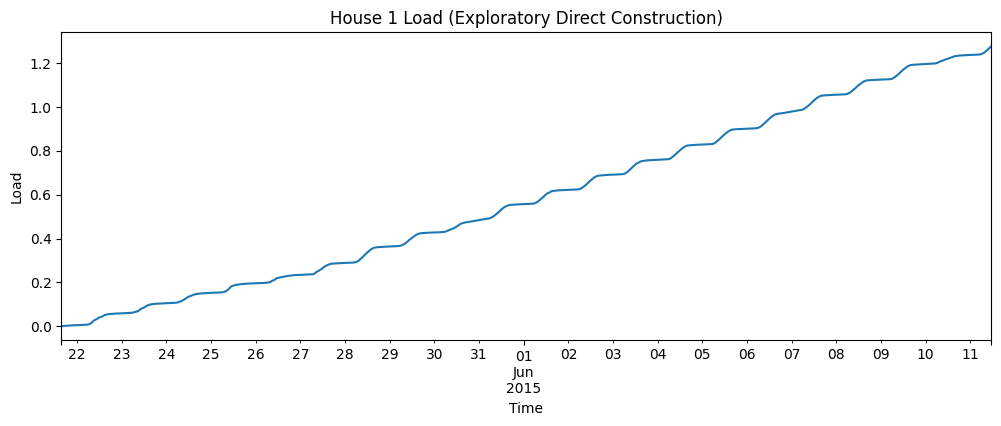

In [6]:
# ------------------------------------------------------------
# 6. Plot exploratory direct load for one house before fixing
# ------------------------------------------------------------
house_data[1]["load"].iloc[:2000].plot(figsize=(12, 4))
plt.title("House 1 Load (Exploratory Direct Construction)")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()


In [7]:
# -------------------------------------------------------
# 7. Sanity check on one household using differenced data
# -------------------------------------------------------
house_id = 1

grid_import_col = f"DE_KN_residential{house_id}_grid_import"
pv_col = f"DE_KN_residential{house_id}_pv"
grid_export_col = f"DE_KN_residential{house_id}_grid_export"

house1 = df[[grid_import_col]].copy()

if pv_col in df.columns:
    house1[pv_col] = df[pv_col]
else:
    house1[pv_col] = 0.0

if grid_export_col in df.columns:
    house1[grid_export_col] = df[grid_export_col]
else:
    house1[grid_export_col] = 0.0

house1 = house1.sort_index()
display(house1.head())

,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
utc_timestamp,,,
2014-12-11 17:45:00+00:00,NaN,NaN,0.0
2014-12-11 18:00:00+00:00,NaN,NaN,0.0
2014-12-11 18:15:00+00:00,NaN,NaN,0.0
2014-12-11 18:30:00+00:00,NaN,NaN,0.0
2014-12-11 18:45:00+00:00,NaN,NaN,0.0


In [8]:
# -------------------------------------------------------
# 8. Convert cumulative signals into interval-based values
# -------------------------------------------------------
house1_diff = house1.diff()
display(house1_diff.head())


,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
utc_timestamp,,,
2014-12-11 17:45:00+00:00,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,0.0
2014-12-11 18:15:00+00:00,NaN,NaN,0.0
2014-12-11 18:30:00+00:00,NaN,NaN,0.0
2014-12-11 18:45:00+00:00,NaN,NaN,0.0


In [9]:
# ---------------------------------------
# 9. Build interval-based household load
# ---------------------------------------
house1_diff["load"] = (
    house1_diff[grid_import_col]
    + house1_diff[pv_col]
    - house1_diff[grid_export_col]
)

# Remove negative artifacts and initial NaN
house1_diff["load"] = house1_diff["load"].clip(lower=0)
house1_load = house1_diff[["load"]].dropna().copy()

display(house1_load.head())

,load
utc_timestamp,
2015-05-21 15:45:00+00:00,0.157
2015-05-21 16:00:00+00:00,0.273
2015-05-21 16:15:00+00:00,0.311
2015-05-21 16:30:00+00:00,0.280
2015-05-21 16:45:00+00:00,0.265


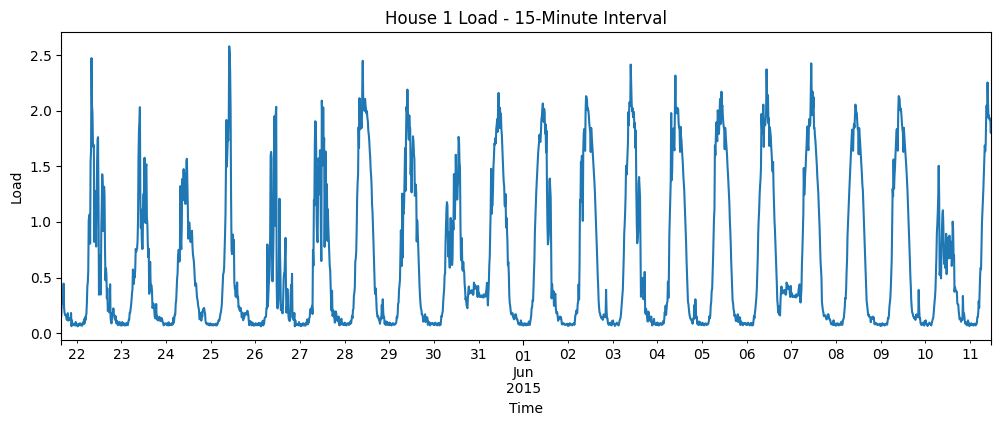

In [10]:
# --------------------------------------
# 10. Visual sanity check for final load
# --------------------------------------
house1_load["load"].iloc[:2000].plot(figsize=(12, 4))
plt.title("House 1 Load - 15-Minute Interval")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

In [11]:
# --------------------------------------------------
# 11. Inspect statistics and interval consistency
# --------------------------------------------------
display(house1_load["load"].describe())
display(house1_load.index.to_series().diff().value_counts().head())

count    63486.000000
mean         0.403525
std          0.502228
min          0.029000
25%          0.105000
50%          0.165000
75%          0.449000
max          3.198000
Name: load, dtype: float64

utc_timestamp
0 days 00:15:00    63485
Name: count, dtype: int64

In [12]:
# ---------------------------------------------------------
# 12. Build final interval-based load for all households
# ---------------------------------------------------------
house_data = {}

for house_id in residential_ids:
    grid_import_col = f"DE_KN_residential{house_id}_grid_import"
    pv_col = f"DE_KN_residential{house_id}_pv"
    grid_export_col = f"DE_KN_residential{house_id}_grid_export"

    house_df = df[[grid_import_col]].copy()

    if pv_col in df.columns:
        house_df[pv_col] = df[pv_col]
    else:
        house_df[pv_col] = 0.0

    if grid_export_col in df.columns:
        house_df[grid_export_col] = df[grid_export_col]
    else:
        house_df[grid_export_col] = 0.0

    house_df = house_df.sort_index()

    house_diff = house_df.diff()

    house_diff["load"] = (
        house_diff[grid_import_col]
        + house_diff[pv_col]
        - house_diff[grid_export_col]
    )

    house_diff["load"] = house_diff["load"].clip(lower=0)
    house_load = house_diff[["load"]].dropna().copy()

    house_data[house_id] = house_load

for house_id in residential_ids:
    print(f"House {house_id}: {house_data[house_id].shape}")

House 1: (63486, 1)
House 2: (63189, 1)
House 3: (47611, 1)
House 4: (81434, 1)
House 5: (123210, 1)
House 6: (66754, 1)


In [13]:
# -------------------------------------------------------
# 13. Select one household for forecasting experiments
# -------------------------------------------------------
house_id = 1
df_house = house_data[house_id].copy()

display(df_house.head())

,load
utc_timestamp,
2015-05-21 15:45:00+00:00,0.157
2015-05-21 16:00:00+00:00,0.273
2015-05-21 16:15:00+00:00,0.311
2015-05-21 16:30:00+00:00,0.280
2015-05-21 16:45:00+00:00,0.265


In [14]:
# ------------------------------------------
# 14. Convert index to timezone-aware format
# ------------------------------------------
df_house.index = pd.to_datetime(df_house.index, utc=False)
print(type(df_house.index))

<class 'pandas.DatetimeIndex'>


In [15]:
# -----------------------------------
# 15. Create initial calendar features
# -----------------------------------
import holidays

df_house["hour"] = df_house.index.hour
df_house["day_of_week"] = df_house.index.dayofweek
df_house["month"] = df_house.index.month
df_house["is_weekend"] = (df_house["day_of_week"] >= 5).astype(int)
de_holidays = holidays.Germany()
df_house["is_holiday"] = df_house.index.tz_localize(None).normalize().map(
    lambda d: int(d in de_holidays)
)

display(df_house.head())

,load,hour,day_of_week,month,is_weekend,is_holiday
utc_timestamp,,,,,,
2015-05-21 15:45:00+00:00,0.157,15,3,5,0,0
2015-05-21 16:00:00+00:00,0.273,16,3,5,0,0
2015-05-21 16:15:00+00:00,0.311,16,3,5,0,0
2015-05-21 16:30:00+00:00,0.280,16,3,5,0,0
2015-05-21 16:45:00+00:00,0.265,16,3,5,0,0


In [16]:
# --------------------------
# 16. Create lag features
# --------------------------
df_house["lag_1"] = df_house["load"].shift(1)      # 15 minutes ago
df_house["lag_4"] = df_house["load"].shift(4)      # 1 hour ago
df_house["lag_96"] = df_house["load"].shift(96)    # 24 hours ago

display(df_house.head())

,load,hour,day_of_week,month,is_weekend,is_holiday,lag_1,lag_4,lag_96
utc_timestamp,,,,,,,,,
2015-05-21 15:45:00+00:00,0.157,15,3,5,0,0,NaN,NaN,NaN
2015-05-21 16:00:00+00:00,0.273,16,3,5,0,0,0.157,NaN,NaN
2015-05-21 16:15:00+00:00,0.311,16,3,5,0,0,0.273,NaN,NaN
2015-05-21 16:30:00+00:00,0.280,16,3,5,0,0,0.311,NaN,NaN
2015-05-21 16:45:00+00:00,0.265,16,3,5,0,0,0.280,0.157,NaN


In [17]:
# --------------------------------------------
# 17. Drop rows with missing lag values
# --------------------------------------------
df_house = df_house.dropna()
display(df_house.head())

,load,hour,day_of_week,month,is_weekend,is_holiday,lag_1,lag_4,lag_96
utc_timestamp,,,,,,,,,
2015-05-22 15:45:00+00:00,0.584,15,4,5,0,0,0.475,1.318,0.157
2015-05-22 16:00:00+00:00,0.529,16,4,5,0,0,0.584,1.231,0.273
2015-05-22 16:15:00+00:00,0.313,16,4,5,0,0,0.529,0.754,0.311
2015-05-22 16:30:00+00:00,0.403,16,4,5,0,0,0.313,0.475,0.280
2015-05-22 16:45:00+00:00,0.200,16,4,5,0,0,0.403,0.584,0.265


In [18]:
# -------------------------------
# 18. Create rolling mean features
# -------------------------------
df_house["rolling_mean_1h"] = df_house["load"].rolling(4).mean()
df_house["rolling_mean_24h"] = df_house["load"].rolling(96).mean()

display(df_house.head())


,load,hour,day_of_week,month,is_weekend,is_holiday,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h
utc_timestamp,,,,,,,,,,,
2015-05-22 15:45:00+00:00,0.584,15,4,5,0,0,0.475,1.318,0.157,NaN,NaN
2015-05-22 16:00:00+00:00,0.529,16,4,5,0,0,0.584,1.231,0.273,NaN,NaN
2015-05-22 16:15:00+00:00,0.313,16,4,5,0,0,0.529,0.754,0.311,NaN,NaN
2015-05-22 16:30:00+00:00,0.403,16,4,5,0,0,0.313,0.475,0.280,0.45725,NaN
2015-05-22 16:45:00+00:00,0.200,16,4,5,0,0,0.403,0.584,0.265,0.36125,NaN


In [19]:
# ------------------------------------------------
# 19. Drop rows with missing rolling values
# ------------------------------------------------
df_house = df_house.dropna()

display(df_house.head())
print("Final feature-engineered dataset shape:", df_house.shape)


,load,hour,day_of_week,month,is_weekend,is_holiday,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h
utc_timestamp,,,,,,,,,,,
2015-05-23 15:30:00+00:00,0.642,15,5,5,1,0,0.374,0.682,0.475,0.53250,0.483885
2015-05-23 15:45:00+00:00,0.456,15,5,5,1,0,0.642,0.760,0.584,0.45650,0.482552
2015-05-23 16:00:00+00:00,0.431,16,5,5,1,0,0.456,0.354,0.529,0.47575,0.481531
2015-05-23 16:15:00+00:00,0.431,16,5,5,1,0,0.431,0.374,0.313,0.49000,0.482760
2015-05-23 16:30:00+00:00,0.381,16,5,5,1,0,0.431,0.642,0.403,0.42475,0.482531


Final feature-engineered dataset shape: (63295, 11)


In [20]:
# ---------------------------------------------------------
# 20. Build single-step target for 24-hour-ahead forecasting
# ---------------------------------------------------------
# 96 steps = 24 hours because data is sampled every 15 minutes
df_house["target"] = df_house["load"].shift(-96)
df_house = df_house.dropna()

display(df_house.head())

,load,hour,day_of_week,month,is_weekend,is_holiday,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h,target
utc_timestamp,,,,,,,,,,,,
2015-05-23 15:30:00+00:00,0.642,15,5,5,1,0,0.374,0.682,0.475,0.53250,0.483885,0.488
2015-05-23 15:45:00+00:00,0.456,15,5,5,1,0,0.642,0.760,0.584,0.45650,0.482552,0.426
2015-05-23 16:00:00+00:00,0.431,16,5,5,1,0,0.456,0.354,0.529,0.47575,0.481531,0.451
2015-05-23 16:15:00+00:00,0.431,16,5,5,1,0,0.431,0.374,0.313,0.49000,0.482760,0.440
2015-05-23 16:30:00+00:00,0.381,16,5,5,1,0,0.431,0.642,0.403,0.42475,0.482531,0.366


In [21]:
# -----------------------------------------
# 21. Separate features and target variable
# -----------------------------------------
X = df_house.drop(columns=["load", "target"])
y = df_house["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (63199, 10)
y shape: (63199,)


In [22]:
# --------------------------------------------------
# 22. Chronological train / validation / test split
# --------------------------------------------------
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (44239, 10) (44239,)
Validation: (9480, 10) (9480,)
Test: (9480, 10) (9480,)


In [23]:
# ---------------------------------------------
# 23. Define single-step baseline regression models
# ---------------------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

In [24]:
# ---------------------------------------------
# 24. Train and evaluate baseline models
# ---------------------------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1323
[LightGBM] [Info] Number of data points in the train set: 44239, number of used features: 10
[LightGBM] [Info] Start training from score 0.444155


c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\subprocess.py", l

,model,MAE,RMSE
5,LightGBM,0.142101,0.258931
0,LinearRegression,0.154334,0.259569
1,Ridge,0.154337,0.259570
3,RandomForest,0.150627,0.267832
4,XGBoost,0.149036,0.272700
2,DecisionTree,0.191056,0.357095


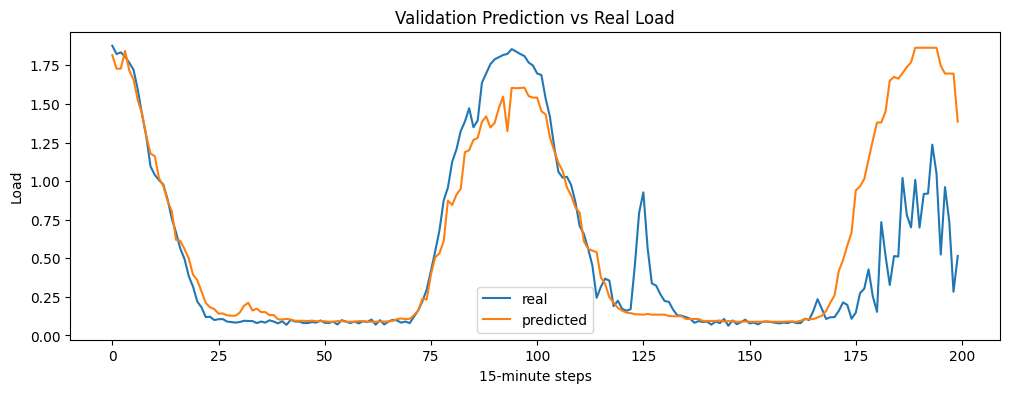

In [25]:
# -----------------------------------------------------------
# 25. Visual comparison for the best single-step baseline
# -----------------------------------------------------------
best_model = models["LightGBM"]
y_val_pred = best_model.predict(X_val)

plt.figure(figsize=(12, 4))
plt.plot(y_val.values[:200], label="real")
plt.plot(y_val_pred[:200], label="predicted")
plt.legend()
plt.title("Validation Prediction vs Real Load")
plt.xlabel("15-minute steps")
plt.ylabel("Load")
plt.show()

In [26]:
# -------------------------------------------------------
# 26. Build direct multi-step targets for next 24 hours
# -------------------------------------------------------
horizon = 96
y_multi = pd.DataFrame(index=df_house.index)

for h in range(1, horizon + 1):
    y_multi[f"target_t+{h}"] = df_house["load"].shift(-h)

display(y_multi.head())

,target_t+1,target_t+2,target_t+3,target_t+4,target_t+5,target_t+6,target_t+7,target_t+8,target_t+9,target_t+10,...,target_t+87,target_t+88,target_t+89,target_t+90,target_t+91,target_t+92,target_t+93,target_t+94,target_t+95,target_t+96
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2015-05-23 15:30:00+00:00,0.456,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,...,0.819,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488
2015-05-23 15:45:00+00:00,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,...,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426
2015-05-23 16:00:00+00:00,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,...,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451
2015-05-23 16:15:00+00:00,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,...,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440
2015-05-23 16:30:00+00:00,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,...,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366


In [27]:
# --------------------------------------------------------
# 27. Align feature matrix with multi-step target matrix
# --------------------------------------------------------
data_multi = pd.concat([X, y_multi], axis=1).dropna()
print("Aligned multi-step dataset shape:", data_multi.shape)

Aligned multi-step dataset shape: (63103, 106)


In [28]:
# ---------------------------------------------------
# 28. Separate multi-step inputs and targets
# ---------------------------------------------------
X_multi = data_multi[X.columns]
y_multi = data_multi[y_multi.columns]

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (63103, 10)
y_multi shape: (63103, 96)


In [29]:
# ---------------------------------------------------------
# 29. Chronological split for multi-step forecasting
# ---------------------------------------------------------
n = len(X_multi)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_multi.iloc[:train_end]
y_train = y_multi.iloc[:train_end]

X_val = X_multi.iloc[train_end:val_end]
y_val = y_multi.iloc[train_end:val_end]

X_test = X_multi.iloc[val_end:]
y_test = y_multi.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (44172, 10) (44172, 96)
Validation: (9465, 10) (9465, 96)
Test: (9466, 10) (9466, 96)


In [30]:
# ---------------------------------------------------------
# 30. Train baseline multi-output LightGBM model
# ---------------------------------------------------------
multi_lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        random_state=42
    )
)

multi_lgbm.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1323
[LightGBM] [Info] Number of data points in the train set: 44172, number of used features: 10
[LightGBM] [Info] Start training from score 0.443631
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1323
[LightGBM] [Info] Number of data points in the train set: 44172, number of used features: 10
[LightGBM] [Info] Start training from score 0.443624
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

MultiOutputRegressor(estimator=LGBMRegressor(random_state=42))

In [31]:
# ---------------------------------------------------------
# 31. Generate validation forecasts for all 96 steps
# ---------------------------------------------------------
y_val_pred = multi_lgbm.predict(X_val)
print("Validation prediction shape:", y_val_pred.shape)

Validation prediction shape: (9465, 96)


In [32]:
# ---------------------------------------------------------
# 32. Compute overall multi-step validation metrics
# ---------------------------------------------------------
mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation MAE: 0.1455311247910328
Validation RMSE: 0.26187426897635185


In [33]:
# ---------------------------------------------------------
# 33. Compute MAE for each prediction horizon
# ---------------------------------------------------------
mae_per_step = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_val.iloc[:, h], y_val_pred[:, h])
    mae_per_step.append(mae_h)

print("First 10 MAE values by step:")
print(mae_per_step[:10])

First 10 MAE values by step:
[0.0766013125058429, 0.09031920641459151, 0.09771851451892187, 0.10587678341976542, 0.11074207447843604, 0.11598084982263174, 0.11999479065152012, 0.12425445091759842, 0.12721133828664233, 0.1303179866958237]


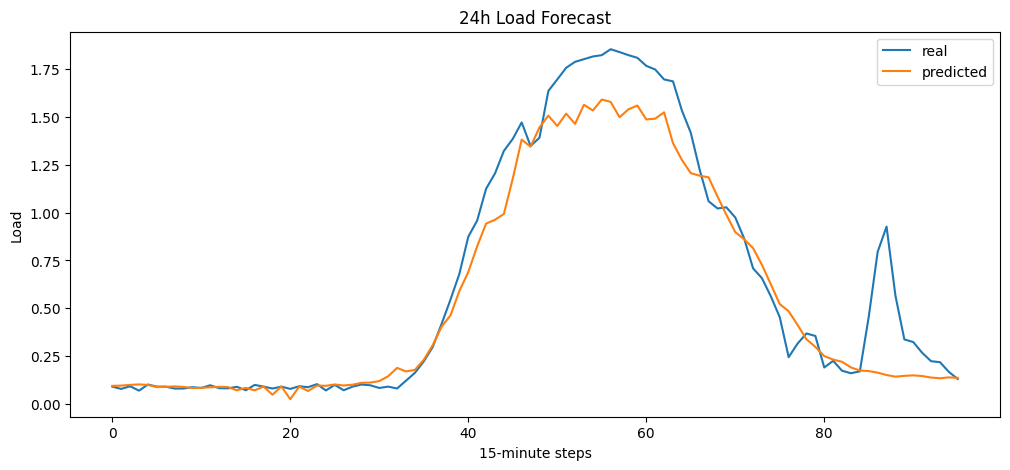

In [34]:
# ---------------------------------------------------------
# 34. Plot one full 24-hour forecast example
# ---------------------------------------------------------
sample = 200

plt.figure(figsize=(12, 5))
plt.plot(y_val.iloc[sample].values, label="real")
plt.plot(y_val_pred[sample], label="predicted")
plt.title("24h Load Forecast")
plt.xlabel("15-minute steps")
plt.ylabel("Load")
plt.legend()
plt.show()

In [35]:
# ---------------------------------------------------------
# 35. Define hyperparameter search space
# ---------------------------------------------------------
param_grid = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": 10,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]


In [36]:
# ---------------------------------------------------------
# 36. Run hyperparameter tuning on validation set
# ---------------------------------------------------------
tuning_results = []

for i, params in enumerate(param_grid, start=1):
    print(f"Running config {i}/{len(param_grid)} ...")

    model = MultiOutputRegressor(
        LGBMRegressor(
            random_state=42,
            verbosity=-1,
            **params
        )
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

    row = params.copy()
    row["MAE"] = mae
    row["RMSE"] = rmse
    tuning_results.append(row)

tuning_results_df = pd.DataFrame(tuning_results).sort_values("RMSE")
display(tuning_results_df)

Running config 1/4 ...
Running config 2/4 ...
Running config 3/4 ...
Running config 4/4 ...


,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,MAE,RMSE
0,100,0.05,31,-1,20,1.0,1.0,0.144079,0.255715
2,200,0.03,63,-1,20,0.8,0.8,0.143811,0.257455
1,200,0.05,31,-1,20,1.0,1.0,0.144919,0.260685
3,300,0.03,63,10,30,0.8,0.8,0.144954,0.260909


In [37]:
# ---------------------------------------------------------
# 37. Retrain final model on train + validation sets
# ---------------------------------------------------------
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        verbosity=-1
    )
)

final_model.fit(X_train_full, y_train_full)

MultiOutputRegressor(estimator=LGBMRegressor(learning_rate=0.05,
                                             random_state=42, verbosity=-1))

In [38]:
# ---------------------------------------------------------
# 38. Evaluate final tuned model on test set
# ---------------------------------------------------------
y_test_pred = final_model.predict(X_test)

mae_test = mean_absolute_error(y_test.values.flatten(), y_test_pred.flatten())
rmse_test = np.sqrt(mean_squared_error(y_test.values.flatten(), y_test_pred.flatten()))

print("TEST MAE:", mae_test)
print("TEST RMSE:", rmse_test)

TEST MAE: 0.11257534467221698
TEST RMSE: 0.1995896888878518


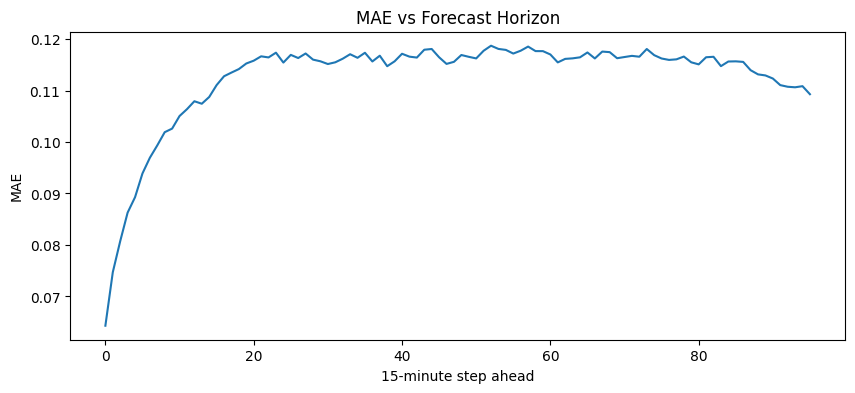

In [39]:
# ---------------------------------------------------------
# 39. Analyze test error across the full forecast horizon
# ---------------------------------------------------------
mae_per_step_test = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_test.iloc[:, h], y_test_pred[:, h])
    mae_per_step_test.append(mae_h)

plt.figure(figsize=(10, 4))
plt.plot(mae_per_step_test)
plt.title("MAE vs Forecast Horizon")
plt.xlabel("15-minute step ahead")
plt.ylabel("MAE")
plt.show()

In [40]:
# ---------------------------------------------------------
# 40. Save final model for later HEMS integration
# ---------------------------------------------------------
joblib.dump(final_model, "../models/load_forecast_model.pkl")

['../models/load_forecast_model.pkl']

In [41]:
# ---------------------------------------------------------
# 41. Reload model to verify persistence
# ---------------------------------------------------------
model = joblib.load("../models/load_forecast_model.pkl")

In [42]:
# ---------------------------------------------------------
# 42. Define inference helper function
# ---------------------------------------------------------
def predict_next_24h_load(model, feature_row):
    pred = model.predict(feature_row)
    return pred.flatten()

In [43]:
# =========================================================
# Step 1 — Household Overview
# Goal:
# Inspect all residential households and check which signals
# are available (grid import/export, PV, EV, heat pump).
# This helps justify which households are most suitable
# for deeper EDA and forecasting experiments.
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_csv("../data/household_data_15min_singleindex.csv")

# ---------------------------------------------------------
# Identify timestamp column
# ---------------------------------------------------------
timestamp_col = "cet_cest_timestamp" if "cet_cest_timestamp" in df.columns else "utc_timestamp"

# ---------------------------------------------------------
# Define residential households
# ---------------------------------------------------------
residential_ids = [1, 2, 3, 4, 5, 6]

# ---------------------------------------------------------
# Build overview table
# ---------------------------------------------------------
overview_rows = []

for house_id in residential_ids:
    
    prefix = f"DE_KN_residential{house_id}_"
    
    # Expected key HEMS signals
    grid_import_col = f"{prefix}grid_import"
    grid_export_col = f"{prefix}grid_export"
    pv_col = f"{prefix}pv"
    ev_col = f"{prefix}ev"
    heat_pump_col = f"{prefix}heat_pump"
    
    # All columns belonging to this household
    house_cols = [c for c in df.columns if c.startswith(prefix)]
    
    # Calculate missing values across household columns
    if len(house_cols) > 0:
        total_cells = df[house_cols].shape[0] * df[house_cols].shape[1]
        missing_cells = df[house_cols].isna().sum().sum()
        missing_percent = 100 * missing_cells / total_cells
        non_null_rows = df[house_cols].dropna(how="all").shape[0]
    else:
        missing_percent = np.nan
        non_null_rows = 0

    overview_rows.append({
        "household": f"residential{house_id}",
        "n_columns": len(house_cols),
        "grid_import": grid_import_col in df.columns,
        "grid_export": grid_export_col in df.columns,
        "pv": pv_col in df.columns,
        "ev": ev_col in df.columns,
        "heat_pump": heat_pump_col in df.columns,
        "non_null_rows": non_null_rows,
        "missing_percent_all_house_cols": round(missing_percent, 2) if not np.isnan(missing_percent) else np.nan,
        "columns": ", ".join(house_cols)
    })

overview_df = pd.DataFrame(overview_rows)

# ---------------------------------------------------------
# Add a simple heuristic to indicate HEMS relevance
# ---------------------------------------------------------
def hems_note(row):
    
    if row["ev"] and row["pv"] and row["grid_import"] and row["grid_export"]:
        return "very strong HEMS case"
    
    elif row["pv"] and row["grid_import"] and row["grid_export"]:
        return "strong solar/grid case"
    
    elif row["grid_import"] and row["pv"]:
        return "baseline solar case"
    
    elif row["grid_import"]:
        return "limited case"
    
    else:
        return "weak case"

overview_df["hems_note"] = overview_df.apply(hems_note, axis=1)

# ---------------------------------------------------------
# Display summary table
# ---------------------------------------------------------
display(overview_df[[
    "household",
    "n_columns",
    "grid_import",
    "grid_export",
    "pv",
    "ev",
    "heat_pump",
    "non_null_rows",
    "missing_percent_all_house_cols",
    "hems_note"
]])

# ---------------------------------------------------------
# Optional: show the full list of columns per household
# ---------------------------------------------------------
display(overview_df[["household", "columns"]])

,household,n_columns,grid_import,grid_export,pv,ev,heat_pump,non_null_rows,missing_percent_all_house_cols,hems_note
0,residential1,6,True,False,True,False,True,63487,60.04,baseline solar case
1,residential2,5,True,False,False,False,False,99792,53.33,limited case
2,residential3,8,True,True,True,False,False,132840,33.78,strong solar/grid case
3,residential4,9,True,True,True,True,True,81435,56.77,very strong HEMS case
4,residential5,4,True,False,False,False,False,123211,39.90,limited case
5,residential6,7,True,True,True,False,False,86137,53.38,strong solar/grid case


,household,columns
0,residential1,"DE_KN_residential1_dishwasher, DE_KN_residenti..."
1,residential2,"DE_KN_residential2_circulation_pump, DE_KN_res..."
2,residential3,"DE_KN_residential3_circulation_pump, DE_KN_res..."
3,residential4,"DE_KN_residential4_dishwasher, DE_KN_residenti..."
4,residential5,"DE_KN_residential5_dishwasher, DE_KN_residenti..."
5,residential6,"DE_KN_residential6_circulation_pump, DE_KN_res..."


In [44]:
# =========================================================
# Step 2 — Build interval-based household load
# Goal:
# Convert cumulative signals into interval load
# for ALL households
# =========================================================

eda_source = df.copy()

eda_source[timestamp_col] = pd.to_datetime(eda_source[timestamp_col], utc=True)
eda_source = eda_source.set_index(timestamp_col).sort_index()

houses = [1,2,3,4,5,6]
house_data = {}

for h in houses:
    
    grid_import_col = f"DE_KN_residential{h}_grid_import"
    pv_col = f"DE_KN_residential{h}_pv"
    grid_export_col = f"DE_KN_residential{h}_grid_export"

    house_df = eda_source[[grid_import_col]].copy()

    if pv_col in eda_source.columns:
        house_df[pv_col] = eda_source[pv_col]
    else:
        house_df[pv_col] = 0.0

    if grid_export_col in eda_source.columns:
        house_df[grid_export_col] = eda_source[grid_export_col]
    else:
        house_df[grid_export_col] = 0.0

    house_diff = house_df.diff()

    house_diff["load"] = (
        house_diff[grid_import_col]
        + house_diff[pv_col]
        - house_diff[grid_export_col]
    )

    house_diff["load"] = house_diff["load"].clip(lower=0)

    house_load = house_diff[["load"]].dropna().copy()
    house_load = house_load.rename(columns={"load": f"residential{h}_load"})

    house_data[h] = house_load


# merge all houses
eda_df = pd.concat(
    [house_data[h] for h in houses],
    axis=1
).reset_index()

eda_df = eda_df.rename(columns={timestamp_col: "timestamp"})

display(eda_df.head())
print(eda_df.shape)
print(eda_df.columns)

C:\Users\Mehdi Zamani\AppData\Local\Temp\ipykernel_34760\4073942378.py:51: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  eda_df = pd.concat(


,timestamp,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
0,2015-04-15 09:30:00+00:00,NaN,0.045,NaN,NaN,NaN,NaN
1,2015-04-15 09:45:00+00:00,NaN,0.025,NaN,NaN,NaN,NaN
2,2015-04-15 10:00:00+00:00,NaN,0.020,NaN,NaN,NaN,NaN
3,2015-04-15 10:15:00+00:00,NaN,0.015,NaN,NaN,NaN,NaN
4,2015-04-15 10:30:00+00:00,NaN,0.025,NaN,NaN,NaN,NaN


(141843, 7)
Index(['timestamp', 'residential1_load', 'residential2_load',
       'residential3_load', 'residential4_load', 'residential5_load',
       'residential6_load'],
      dtype='str')


In [45]:
# =========================================================
# Step 3 — Create time features for EDA
# Goal:
# Convert timestamp to datetime and create basic
# calendar features for downstream EDA
# =========================================================

# ensure timestamp is datetime
eda_df["timestamp"] = pd.to_datetime(eda_df["timestamp"], utc=True)

# create basic time features
eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.dayofweek
eda_df["month"] = eda_df["timestamp"].dt.month
eda_df["is_weekend"] = eda_df["day_of_week"] >= 5

# quick check
display(
    eda_df[[
        "timestamp",
        "hour",
        "day_of_week",
        "month",
        "is_weekend"
    ]].head()
)

print(eda_df.dtypes[[
    "timestamp",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]])

,timestamp,hour,day_of_week,month,is_weekend
0,2015-04-15 09:30:00+00:00,9,2,4,False
1,2015-04-15 09:45:00+00:00,9,2,4,False
2,2015-04-15 10:00:00+00:00,10,2,4,False
3,2015-04-15 10:15:00+00:00,10,2,4,False
4,2015-04-15 10:30:00+00:00,10,2,4,False


timestamp      datetime64[us, UTC]
hour                         int32
day_of_week                  int32
month                        int32
is_weekend                    bool
dtype: object


In [46]:
# =========================================================
# Step 4 — Reshape load data for cross-household comparison
# Goal:
# Keep all valid load observations and prepare a long-format
# dataframe for EDA across all households.
# =========================================================

load_cols = [f"residential{i}_load" for i in range(1, 7)]

# convert wide format to long format
eda_long = eda_df.melt(
    id_vars=["timestamp", "hour", "day_of_week", "month", "is_weekend"],
    value_vars=load_cols,
    var_name="household",
    value_name="load"
)

# remove rows where load is missing
eda_long = eda_long.dropna(subset=["load"]).copy()

# clean household labels
eda_long["household"] = eda_long["household"].str.replace("_load", "", regex=False)

# quick checks
print("Long-format EDA shape:", eda_long.shape)
display(eda_long.head())

# show how many valid observations each household has
coverage_df = (
    eda_long.groupby("household")["load"]
    .agg(["count", "mean", "std", "max"])
    .reset_index()
    .rename(columns={
        "count": "n_valid_rows",
        "mean": "mean_load",
        "std": "std_load",
        "max": "max_load"
    })
)

display(coverage_df.sort_values("n_valid_rows", ascending=False))

Long-format EDA shape: (445684, 7)


,timestamp,hour,day_of_week,month,is_weekend,household,load
3481,2015-05-21 15:45:00+00:00,15,3,5,False,residential1,0.157
3482,2015-05-21 16:00:00+00:00,16,3,5,False,residential1,0.273
3483,2015-05-21 16:15:00+00:00,16,3,5,False,residential1,0.311
3484,2015-05-21 16:30:00+00:00,16,3,5,False,residential1,0.280
3485,2015-05-21 16:45:00+00:00,16,3,5,False,residential1,0.265


,household,n_valid_rows,mean_load,std_load,max_load
4,residential5,123210,0.071210,0.075835,1.235
3,residential4,81434,0.195287,0.214002,2.355
5,residential6,66754,0.272615,0.359780,2.544
0,residential1,63486,0.403525,0.502228,3.198
1,residential2,63189,0.071143,0.094229,2.064
2,residential3,47611,0.175988,3.763591,803.940


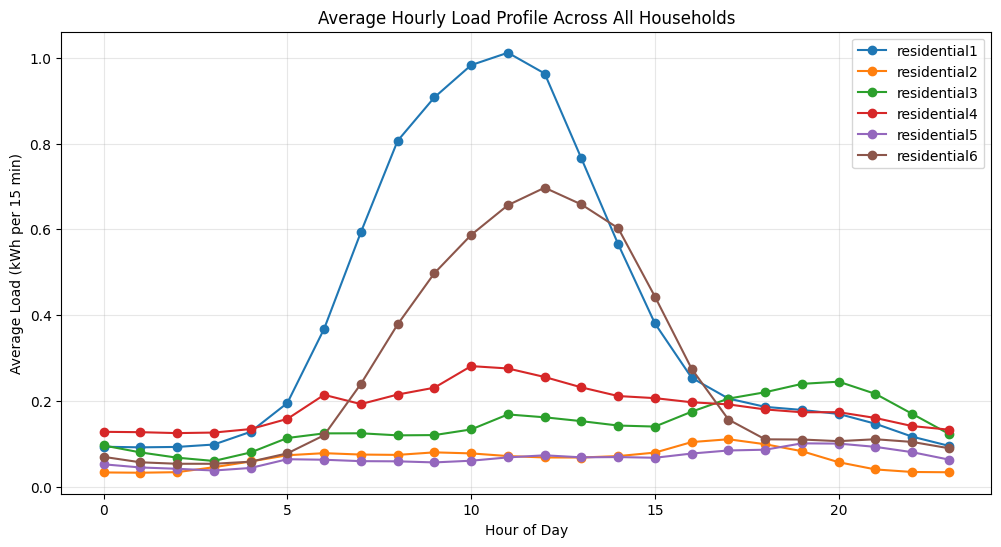

In [47]:
# =========================================================
# Step 5 — Average hourly load profile for all households
# Goal:
# Compare daily consumption patterns across all households.
# A percentile filter is used to reduce the effect of extreme
# outliers in the load signal.
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Remove extreme outliers for visualization only
# ---------------------------------------------------------
q99 = eda_long.groupby("household")["load"].quantile(0.99).to_dict()

eda_long_plot = eda_long.copy()
eda_long_plot["q99"] = eda_long_plot["household"].map(q99)

eda_long_plot = eda_long_plot[eda_long_plot["load"] <= eda_long_plot["q99"]].copy()

# ---------------------------------------------------------
# Compute hourly average load per household
# ---------------------------------------------------------
hourly_profile_df = (
    eda_long_plot
    .groupby(["household", "hour"], as_index=False)["load"]
    .mean()
)

# ---------------------------------------------------------
# Plot hourly profiles
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for household in sorted(hourly_profile_df["household"].unique()):
    
    temp = hourly_profile_df[hourly_profile_df["household"] == household]
    
    plt.plot(
        temp["hour"],
        temp["load"],
        marker="o",
        label=household
    )

plt.title("Average Hourly Load Profile Across All Households")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (kWh per 15 min)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

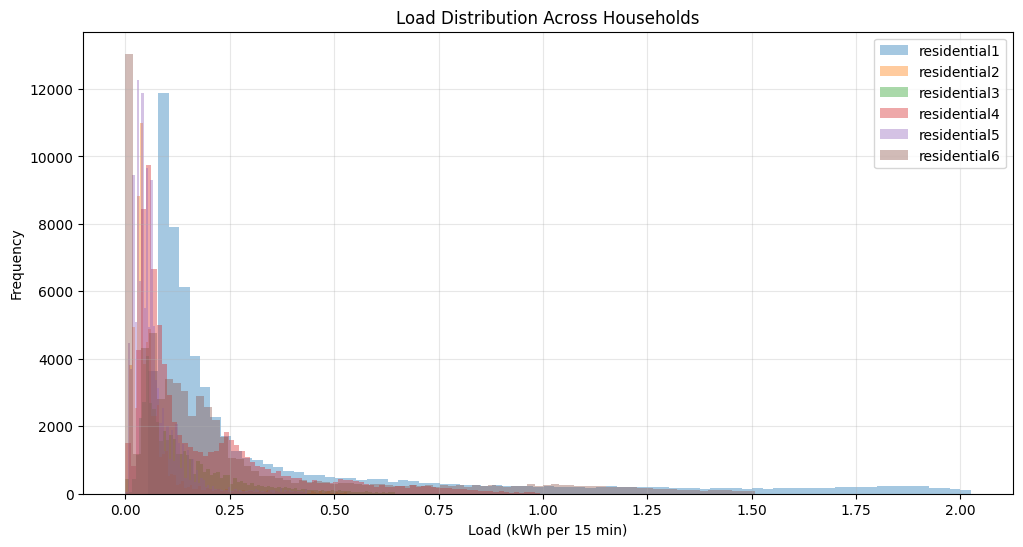

In [48]:
# =========================================================
# Step 6 — Load distribution across all households
# Goal:
# Compare the distribution of load values across households.
# Extreme outliers are filtered for visualization stability.
# =========================================================

import matplotlib.pyplot as plt

# remove extreme outliers (same logic as Step 5)
q99 = eda_long.groupby("household")["load"].quantile(0.99).to_dict()

eda_long_plot = eda_long.copy()
eda_long_plot["q99"] = eda_long_plot["household"].map(q99)

eda_long_plot = eda_long_plot[
    eda_long_plot["load"] <= eda_long_plot["q99"]
]

# ---------------------------------------------------------
# Plot load distributions
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

for household in sorted(eda_long_plot["household"].unique()):

    subset = eda_long_plot[eda_long_plot["household"] == household]

    plt.hist(
        subset["load"],
        bins=80,
        alpha=0.4,
        label=household
    )

plt.title("Load Distribution Across Households")
plt.xlabel("Load (kWh per 15 min)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

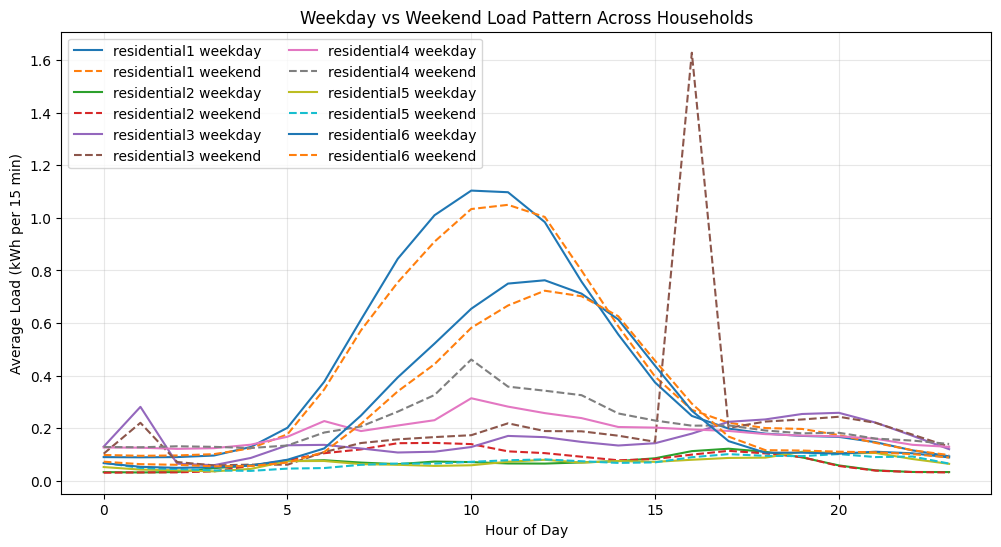

In [49]:
# =========================================================
# Step 7 — Weekday vs Weekend load pattern (All households)
# Goal:
# Compare weekday and weekend hourly consumption
# behaviour across all households
# =========================================================

import matplotlib.pyplot as plt

# compute average load per hour for weekday/weekend
weekday_profile = (
    eda_long[eda_long["is_weekend"] == False]
    .groupby(["household","hour"])["load"]
    .mean()
    .reset_index()
)

weekend_profile = (
    eda_long[eda_long["is_weekend"] == True]
    .groupby(["household","hour"])["load"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

households = sorted(eda_long["household"].unique())

for h in households:

    wday = weekday_profile[weekday_profile["household"] == h]
    wend = weekend_profile[weekend_profile["household"] == h]

    plt.plot(
        wday["hour"],
        wday["load"],
        label=f"{h} weekday"
    )

    plt.plot(
        wend["hour"],
        wend["load"],
        linestyle="--",
        label=f"{h} weekend"
    )

plt.title("Weekday vs Weekend Load Pattern Across Households")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (kWh per 15 min)")

plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.show()

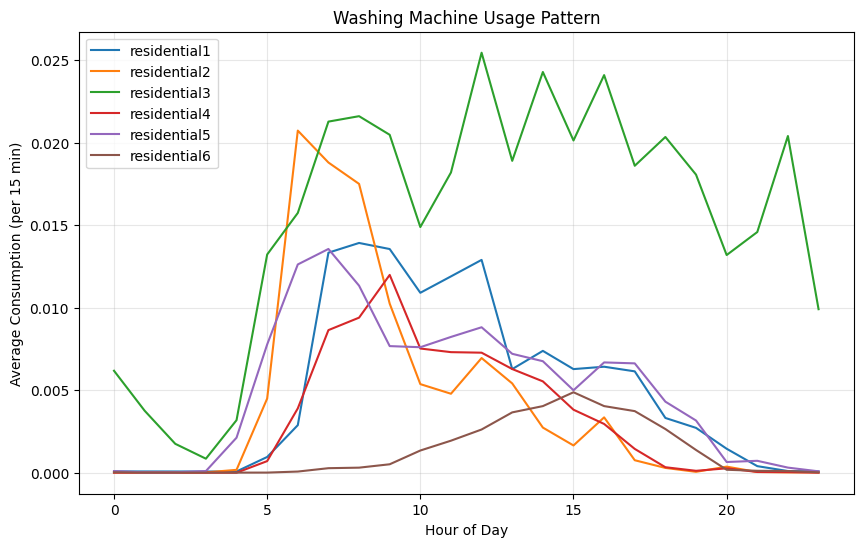

In [50]:
# =========================================================
# Step 8a — Washing machine usage pattern
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# make sure timestamp column exists and is datetime
timestamp_col = "cet_cest_timestamp" if "cet_cest_timestamp" in df.columns else "utc_timestamp"
df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")

# recreate hour safely
df["hour"] = df[timestamp_col].dt.hour

plt.figure(figsize=(10, 6))

washing_cols = [
    c for c in df.columns
    if "residential" in c and "washing_machine" in c
]

for col in washing_cols:
    usage = pd.to_numeric(df[col], errors="coerce").diff().clip(lower=0)

    hourly = (
        pd.DataFrame({
            "usage": usage,
            "hour": df["hour"]
        })
        .dropna()
        .groupby("hour")["usage"]
        .mean()
    )

    house = col.split("_")[2]
    plt.plot(hourly.index, hourly.values, label=house)

plt.title("Washing Machine Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (per 15 min)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

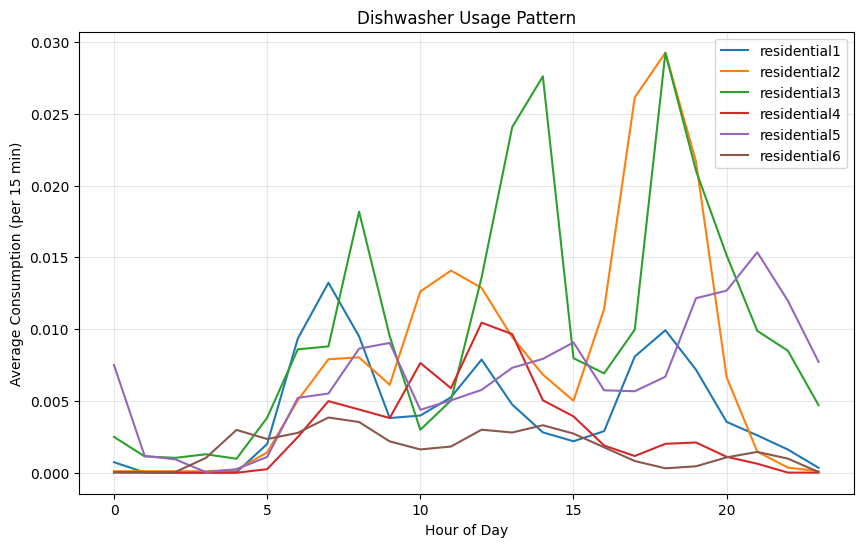

In [51]:
# =========================================================
# Step 8b — Dishwasher usage pattern
# =========================================================

plt.figure(figsize=(10,6))

dishwasher_cols = [
    c for c in df.columns
    if "residential" in c and "dishwasher" in c
]

for col in dishwasher_cols:

    usage = df[col].diff().clip(lower=0)

    hourly = pd.DataFrame({
        "usage": usage,
        "hour": df["hour"]
    }).dropna().groupby("hour")["usage"].mean()

    house = col.split("_")[2]

    plt.plot(hourly.index, hourly.values, label=house)

plt.title("Dishwasher Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (per 15 min)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

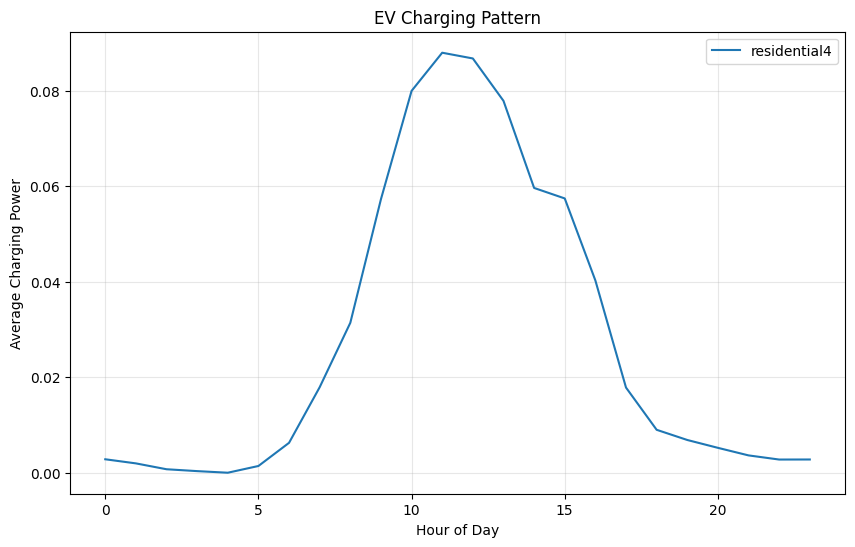

In [52]:
# =========================================================
# Step 8c — EV charging pattern
# =========================================================

plt.figure(figsize=(10,6))

ev_cols = [
    c for c in df.columns
    if "residential" in c and "_ev" in c
]

for col in ev_cols:

    usage = df[col].diff().clip(lower=0)

    hourly = pd.DataFrame({
        "usage": usage,
        "hour": df["hour"]
    }).dropna().groupby("hour")["usage"].mean()

    house = col.split("_")[2]

    plt.plot(hourly.index, hourly.values, label=house)

plt.title("EV Charging Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Charging Power")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

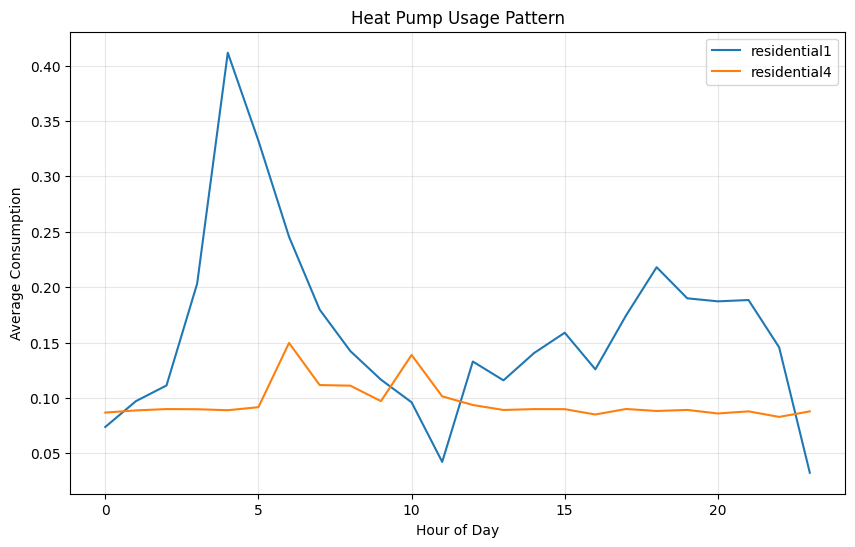

In [53]:
# =========================================================
# Step 8d — Heat pump usage pattern
# =========================================================

plt.figure(figsize=(10,6))

heatpump_cols = [
    c for c in df.columns
    if "residential" in c and "heat_pump" in c
]

for col in heatpump_cols:

    usage = df[col].diff().clip(lower=0)

    hourly = pd.DataFrame({
        "usage": usage,
        "hour": df["hour"]
    }).dropna().groupby("hour")["usage"].mean()

    house = col.split("_")[2]

    plt.plot(hourly.index, hourly.values, label=house)

plt.title("Heat Pump Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [54]:
# =========================================================
# Step 9 — Baseline electricity cost estimation
# Goal:
# Estimate electricity cost using grid import/export
# =========================================================

IMPORT_PRICE_EUR_PER_KWH = 0.30
EXPORT_PRICE_EUR_PER_KWH = 0.08

cost_rows = []

for h in range(1,7):

    import_col = f"DE_KN_residential{h}_grid_import"
    export_col = f"DE_KN_residential{h}_grid_export"

    if import_col not in df.columns:
        continue

    # convert cumulative meters to interval energy
    import_energy = df[import_col].diff().clip(lower=0)

    if export_col in df.columns:
        export_energy = df[export_col].diff().clip(lower=0)
    else:
        export_energy = 0

    total_import = import_energy.sum()
    total_export = export_energy.sum() if isinstance(export_energy, pd.Series) else 0

    import_cost = total_import * IMPORT_PRICE_EUR_PER_KWH
    export_revenue = total_export * EXPORT_PRICE_EUR_PER_KWH
    net_cost = import_cost - export_revenue

    cost_rows.append({
        "household": f"residential{h}",
        "import_kwh": total_import,
        "export_kwh": total_export,
        "import_cost_eur": import_cost,
        "export_revenue_eur": export_revenue,
        "net_cost_eur": net_cost
    })

cost_df = pd.DataFrame(cost_rows)

display(cost_df)

,household,import_kwh,export_kwh,import_cost_eur,export_revenue_eur,net_cost_eur
0,residential1,9096.355,0.000,2728.9065,0.00000,2728.90650
1,residential2,4495.448,0.000,1348.6344,0.00000,1348.63440
2,residential3,5778.085,9388.804,1733.4255,751.10432,982.32118
3,residential4,10247.073,19070.750,3074.1219,1525.66000,1548.46190
4,residential5,8773.780,0.000,2632.1340,0.00000,2632.13400
5,residential6,7348.299,3443.150,2204.4897,275.45200,1929.03770


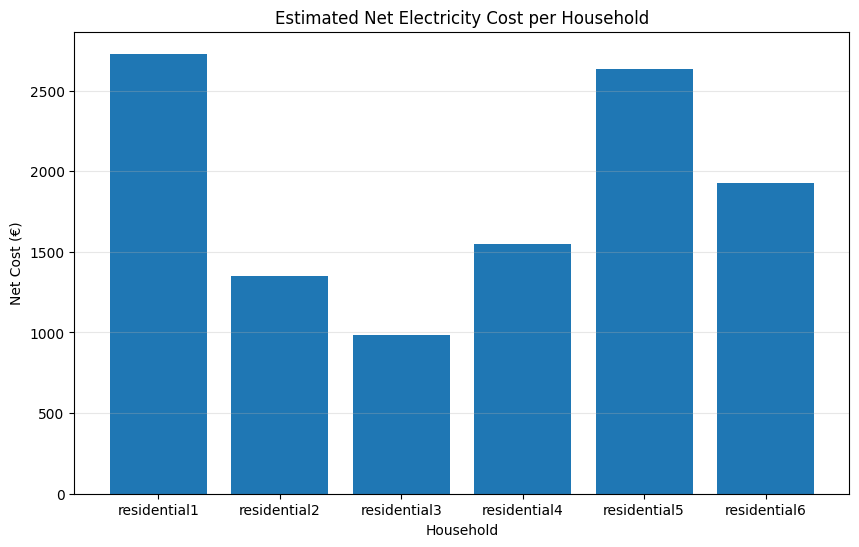

In [55]:
# =========================================================
# Step 10 — Plot electricity cost comparison
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(cost_df["household"], cost_df["net_cost_eur"])

plt.title("Estimated Net Electricity Cost per Household")
plt.xlabel("Household")
plt.ylabel("Net Cost (€)")
plt.grid(axis="y", alpha=0.3)

plt.show()

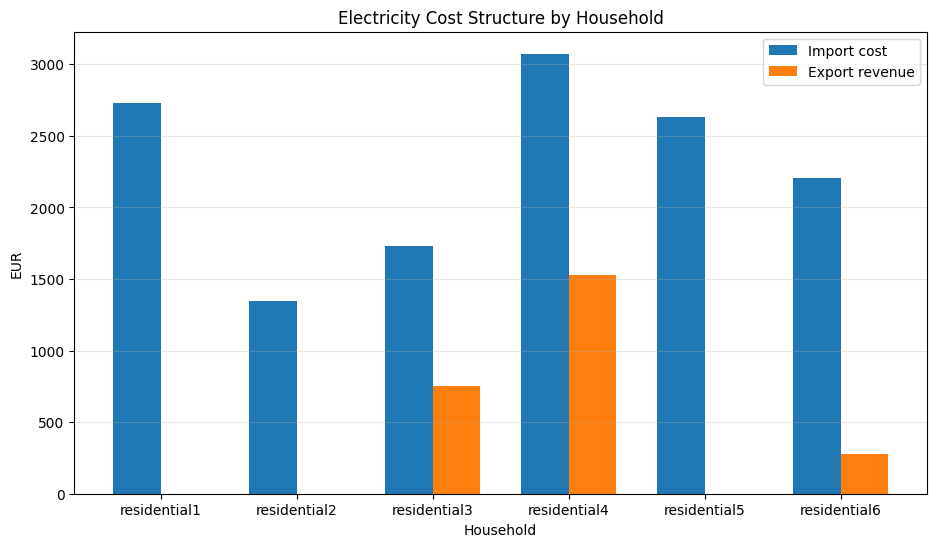

In [56]:
# =========================================================
# Step 11 — Cost structure comparison
# =========================================================

import numpy as np

x = np.arange(len(cost_df))
width = 0.35

plt.figure(figsize=(11,6))

plt.bar(
    x - width/2,
    cost_df["import_cost_eur"],
    width,
    label="Import cost"
)

plt.bar(
    x + width/2,
    cost_df["export_revenue_eur"],
    width,
    label="Export revenue"
)

plt.xticks(x, cost_df["household"])

plt.title("Electricity Cost Structure by Household")
plt.xlabel("Household")
plt.ylabel("EUR")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

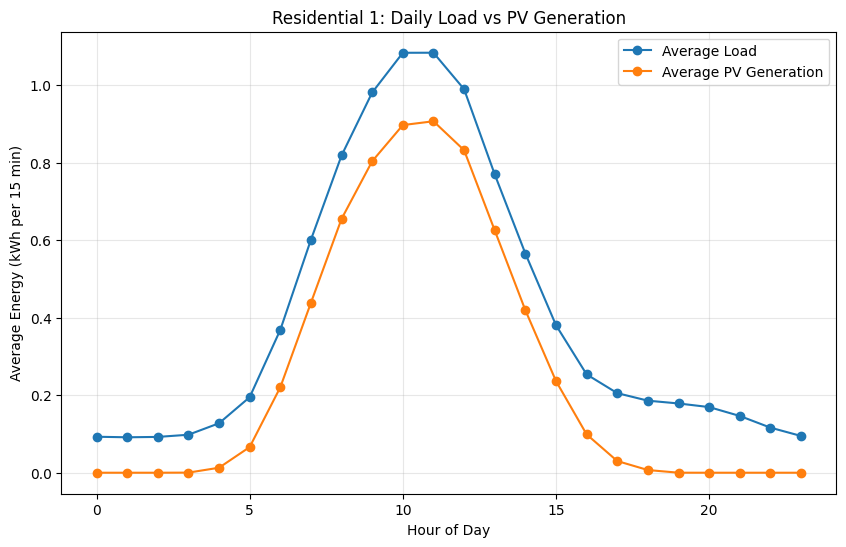

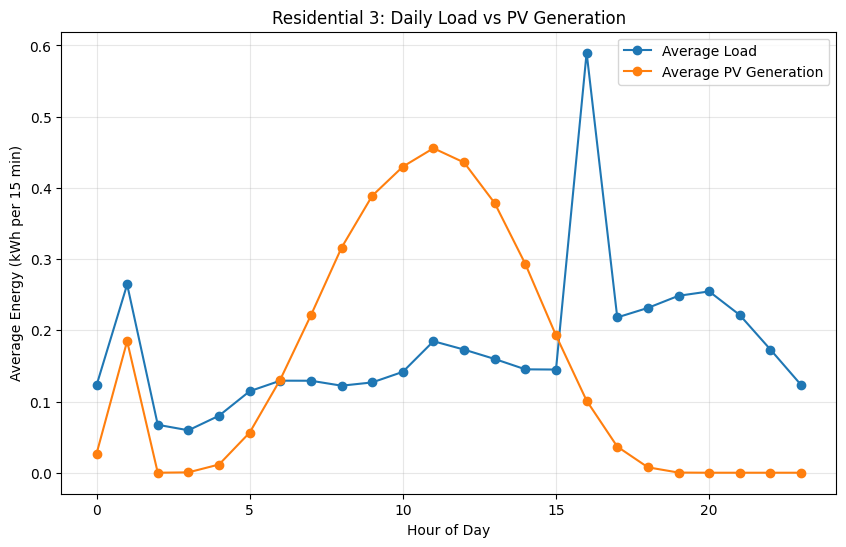

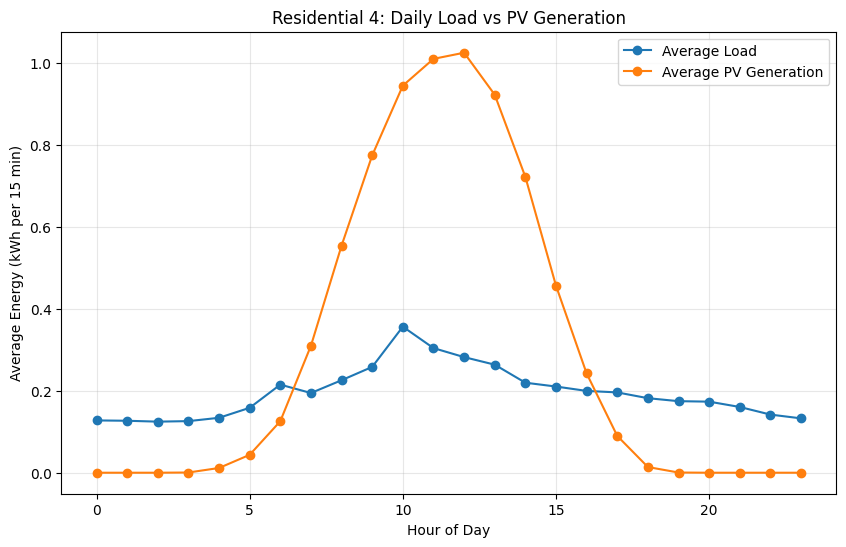

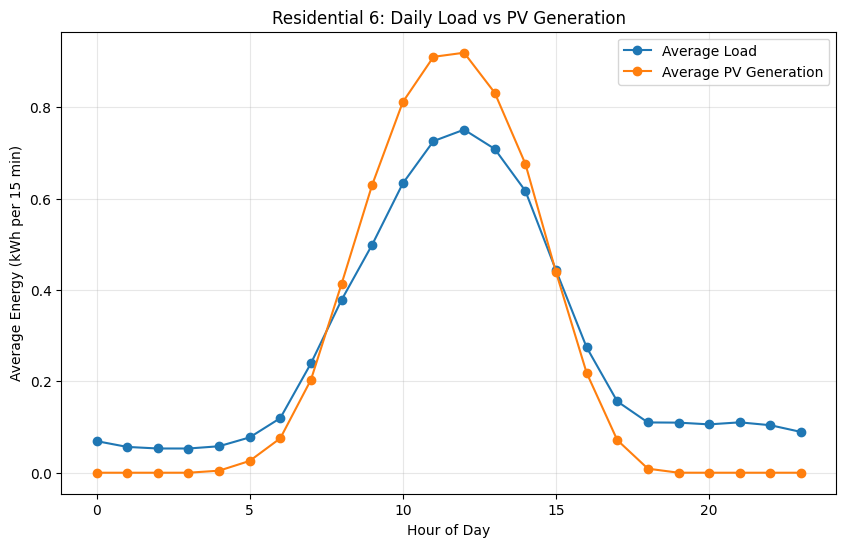

In [57]:
# =========================================================
# Step 12 — Daily load vs PV generation
# Goal:
# Compare average household load and PV generation
# over the course of a day for PV-enabled households
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd

# make sure timestamp and hour exist
df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True)
df["hour"] = df[timestamp_col].dt.hour

# households with PV in this dataset
pv_houses = [1, 3, 4, 6]

for h in pv_houses:
    
    load_col = f"residential{h}_load"
    pv_col = f"DE_KN_residential{h}_pv"
    
    if load_col not in eda_df.columns or pv_col not in df.columns:
        continue

    # convert cumulative PV meter to interval generation
    pv_interval = df[pv_col].diff().clip(lower=0)

    # build temporary dataframe
    temp = pd.DataFrame({
        "hour": df["hour"],
        "pv_generation": pv_interval
    })

    # merge with household load from eda_df using timestamp
    temp = temp.copy()
    temp["timestamp"] = df[timestamp_col].values

    load_temp = eda_df[["timestamp", load_col]].dropna().copy()

    temp["timestamp"] = pd.to_datetime(temp["timestamp"]).dt.tz_localize(None)
    load_temp["timestamp"] = pd.to_datetime(load_temp["timestamp"]).dt.tz_localize(None)

    merged = pd.merge(temp, load_temp, on="timestamp", how="inner")

    if merged.empty:
        continue

    hourly_profile = (
        merged.groupby("hour")[[load_col, "pv_generation"]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        hourly_profile["hour"],
        hourly_profile[load_col],
        marker="o",
        label="Average Load"
    )

    plt.plot(
        hourly_profile["hour"],
        hourly_profile["pv_generation"],
        marker="o",
        label="Average PV Generation"
    )

    plt.title(f"Residential {h}: Daily Load vs PV Generation")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Energy (kWh per 15 min)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [58]:
# =========================================================
# Build energy_master_df for all households
# Goal:
# Create one long-format master table with 15-minute interval
# energy values for key household signals
# =========================================================

import pandas as pd
import numpy as np

df = pd.read_csv("../data/household_data_15min_singleindex.csv")

timestamp_col = "cet_cest_timestamp" if "cet_cest_timestamp" in df.columns else "utc_timestamp"
df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True)
df = df.sort_values(timestamp_col).copy()

houses = [1, 2, 3, 4, 5, 6]
master_rows = []

for h in houses:
    prefix = f"DE_KN_residential{h}_"

    def get_interval_col(col_name):
        full_col = prefix + col_name
        if full_col in df.columns:
            return df[full_col].diff().clip(lower=0)
        else:
            return pd.Series(0.0, index=df.index)

    grid_import = get_interval_col("grid_import")
    grid_export = get_interval_col("grid_export")
    pv = get_interval_col("pv")
    washing_machine = get_interval_col("washing_machine")
    dishwasher = get_interval_col("dishwasher")
    refrigerator = get_interval_col("refrigerator")
    freezer = get_interval_col("freezer")
    circulation_pump = get_interval_col("circulation_pump")
    heat_pump = get_interval_col("heat_pump")
    ev = get_interval_col("ev")

    load = (grid_import + pv - grid_export).clip(lower=0)

    temp_df = pd.DataFrame({
        "timestamp": df[timestamp_col],
        "household": f"residential{h}",
        "grid_import_kwh_15m": grid_import,
        "grid_export_kwh_15m": grid_export,
        "pv_kwh_15m": pv,
        "load_kwh_15m": load,
        "washing_machine_kwh_15m": washing_machine,
        "dishwasher_kwh_15m": dishwasher,
        "refrigerator_kwh_15m": refrigerator,
        "freezer_kwh_15m": freezer,
        "circulation_pump_kwh_15m": circulation_pump,
        "heat_pump_kwh_15m": heat_pump,
        "ev_kwh_15m": ev,
    })

    temp_df = temp_df.dropna(subset=["timestamp"]).copy()
    master_rows.append(temp_df)

energy_master_df = pd.concat(master_rows, ignore_index=True)

display(energy_master_df.head())
print(energy_master_df.shape)

,timestamp,household,grid_import_kwh_15m,grid_export_kwh_15m,pv_kwh_15m,load_kwh_15m,washing_machine_kwh_15m,dishwasher_kwh_15m,refrigerator_kwh_15m,freezer_kwh_15m,circulation_pump_kwh_15m,heat_pump_kwh_15m,ev_kwh_15m
0,2014-12-11 17:45:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
1,2014-12-11 18:00:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
2,2014-12-11 18:15:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
3,2014-12-11 18:30:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
4,2014-12-11 18:45:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0


(922860, 13)


In [59]:
# =========================================================
# Household Summary Table — Numeric decision table
# Goal:
# Build a decision-oriented summary table using real values
# instead of simple True/False flags.
# =========================================================

summary_rows = []

for household, g in energy_master_df.groupby("household"):
    
    # aggregate totals
    total_import = g["grid_import_kwh_15m"].sum()
    total_export = g["grid_export_kwh_15m"].sum()
    total_pv = g["pv_kwh_15m"].sum()
    total_load = g["load_kwh_15m"].sum()
    
    total_washing_machine = g["washing_machine_kwh_15m"].sum()
    total_dishwasher = g["dishwasher_kwh_15m"].sum()
    total_refrigerator = g["refrigerator_kwh_15m"].sum()
    total_freezer = g["freezer_kwh_15m"].sum()
    total_circulation_pump = g["circulation_pump_kwh_15m"].sum()
    total_heat_pump = g["heat_pump_kwh_15m"].sum()
    total_ev = g["ev_kwh_15m"].sum()

    
    appliance_total = (
        total_washing_machine +
        total_dishwasher +
        total_refrigerator +
        total_freezer +
        total_circulation_pump +
        total_heat_pump +
        total_ev
    )
    
    appliance_to_load_ratio = appliance_total / total_load if total_load > 0 else np.nan
    
    
    summary_rows.append({
        "household": household,
        
        "total_import_kwh": round(total_import, 3),
        "total_export_kwh": round(total_export, 3),
        "total_pv_kwh": round(total_pv, 3),
        "total_load_kwh": round(total_load, 3),
        
        "total_washing_machine_kwh": round(total_washing_machine, 3),
        "total_dishwasher_kwh": round(total_dishwasher, 3),
        "total_refrigerator_kwh": round(total_refrigerator, 3),
        "total_freezer_kwh": round(total_freezer, 3),
        "total_circulation_pump_kwh": round(total_circulation_pump, 3),
        "total_heat_pump_kwh": round(total_heat_pump, 3),
        "total_ev_kwh": round(total_ev, 3),


    })

household_summary_df = pd.DataFrame(summary_rows)

display(household_summary_df)

,household,total_import_kwh,total_export_kwh,total_pv_kwh,total_load_kwh,total_washing_machine_kwh,total_dishwasher_kwh,total_refrigerator_kwh,total_freezer_kwh,total_circulation_pump_kwh,total_heat_pump_kwh,total_ev_kwh
0,residential1,9096.355,0.000,16521.802,25618.157,320.321,268.599,0.000,432.756,0.000,10213.523,0.000
1,residential2,4495.448,0.000,0.000,4495.448,428.020,596.351,0.000,140.505,868.884,0.000,0.000
2,residential3,5778.085,9388.804,13673.661,8378.975,1878.474,1175.990,553.362,366.266,1777.351,0.000,0.000
3,residential4,10247.073,19070.750,24576.444,15902.965,158.355,141.800,193.862,354.292,0.000,4728.820,2225.031
4,residential5,8773.780,0.000,0.000,8773.780,476.462,615.505,603.771,0.000,0.000,0.000,0.000
5,residential6,7348.299,3443.150,20495.400,18198.149,78.641,96.078,0.000,146.687,950.710,0.000,0.000


In [60]:
energy_master_df.to_csv("../models/energy_master_table_residential_15min.csv", index=False)

print("Saved energy master table.")

Saved energy master table.


In [61]:
import pandas as pd
import numpy as np
import holidays

def build_next_24h_load_table(model, df_house, household_name="residential1"):
    """
    Build a 24-hour ahead household load forecast table
    with 96 rows at 15-minute resolution.
    """

    # --------------------------------------------------
    # 1. Rebuild feature table exactly like training
    # --------------------------------------------------
    df_inf = df_house.copy()

    df_inf["hour"] = df_inf.index.hour
    df_inf["day_of_week"] = df_inf.index.dayofweek
    df_inf["month"] = df_inf.index.month
    df_inf["is_weekend"] = (df_inf["day_of_week"] >= 5).astype(int)
    de_holidays = holidays.Germany()
    df_inf["is_holiday"] = df_inf.index.tz_localize(None).normalize().map(
    lambda d: int(d in de_holidays)
)

    df_inf["lag_1"] = df_inf["load"].shift(1)
    df_inf["lag_4"] = df_inf["load"].shift(4)
    df_inf["lag_96"] = df_inf["load"].shift(96)

    df_inf["rolling_mean_1h"] = df_inf["load"].rolling(4).mean()
    df_inf["rolling_mean_24h"] = df_inf["load"].rolling(96).mean()

    df_inf = df_inf.dropna().copy()

    # --------------------------------------------------
    # 2. Keep only model input columns
    # --------------------------------------------------
    feature_cols = [
        "hour",
        "day_of_week",
        "month",
        "is_weekend",
        "is_holiday",
        "lag_1",
        "lag_4",
        "lag_96",
        "rolling_mean_1h",
        "rolling_mean_24h",
    ]

    X_latest = df_inf[feature_cols].iloc[[-1]]

    # --------------------------------------------------
    # 3. Predict next 96 steps
    # --------------------------------------------------
    y_pred = model.predict(X_latest).flatten()

    # --------------------------------------------------
    # 4. Create future timestamps
    # --------------------------------------------------
    last_time = df_inf.index[-1]
    future_times = pd.date_range(
        start=last_time + pd.Timedelta(minutes=15),
        periods=96,
        freq="15min"
    )

    # --------------------------------------------------
    # 5. Build output table
    # --------------------------------------------------
    forecast_table = pd.DataFrame({
        "time": future_times,
        "predicted_kwh": np.round(y_pred, 4),
        "predicted_kw": np.round(y_pred * 4, 4),   # because 15 min = 0.25 h
        "household": household_name,
        "source": "lightgbm_load_forecast"
    })

    return forecast_table

In [62]:
load_forecast_table = build_next_24h_load_table(
    model=final_model,
    df_house=house_data[1].copy().rename(columns={"residential1_load": "load"}),
    household_name="residential1"
)

display(load_forecast_table.head(12))
print(load_forecast_table.shape)

,time,predicted_kwh,predicted_kw,household,source
0,2017-03-12 23:15:00+00:00,0.0892,0.3567,residential1,lightgbm_load_forecast
1,2017-03-12 23:30:00+00:00,0.0898,0.3593,residential1,lightgbm_load_forecast
2,2017-03-12 23:45:00+00:00,0.0910,0.3641,residential1,lightgbm_load_forecast
3,2017-03-13 00:00:00+00:00,0.0903,0.3612,residential1,lightgbm_load_forecast
4,2017-03-13 00:15:00+00:00,0.0900,0.3600,residential1,lightgbm_load_forecast
5,2017-03-13 00:30:00+00:00,0.0901,0.3603,residential1,lightgbm_load_forecast
6,2017-03-13 00:45:00+00:00,0.0921,0.3683,residential1,lightgbm_load_forecast
7,2017-03-13 01:00:00+00:00,0.0934,0.3734,residential1,lightgbm_load_forecast
8,2017-03-13 01:15:00+00:00,0.0950,0.3799,residential1,lightgbm_load_forecast
9,2017-03-13 01:30:00+00:00,0.0956,0.3824,residential1,lightgbm_load_forecast


(96, 5)


In [63]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [64]:
from example_files.load import get_daily_load_forecast

In [65]:
load_forecast_table = get_daily_load_forecast(
    target_date="2026-03-17",
    household_id=1
)

display(load_forecast_table.head(12))
print(load_forecast_table.shape)

,time,predicted_kwh,predicted_kw,household,source
0,2026-03-17 00:00:00+00:00,0.0892,0.3567,residential1,baseline_load_model
1,2026-03-17 00:15:00+00:00,0.0898,0.3593,residential1,baseline_load_model
2,2026-03-17 00:30:00+00:00,0.0910,0.3641,residential1,baseline_load_model
3,2026-03-17 00:45:00+00:00,0.0903,0.3612,residential1,baseline_load_model
4,2026-03-17 01:00:00+00:00,0.0900,0.3600,residential1,baseline_load_model
5,2026-03-17 01:15:00+00:00,0.0901,0.3603,residential1,baseline_load_model
6,2026-03-17 01:30:00+00:00,0.0921,0.3683,residential1,baseline_load_model
7,2026-03-17 01:45:00+00:00,0.0934,0.3734,residential1,baseline_load_model
8,2026-03-17 02:00:00+00:00,0.0950,0.3799,residential1,baseline_load_model
9,2026-03-17 02:15:00+00:00,0.0956,0.3824,residential1,baseline_load_model


(96, 5)
